# MedXAI — Explicabilité des modèles de classification multi-label
## Approche par Analyse de Concepts Formels (ACF) + Règles Anchor

**Contexte :** Les modèles de machine learning utilisés en médecine sont souvent des "boîtes noires". 
Ce notebook implémente une approche originale d'explicabilité basée sur :
1. L'**Analyse de Concepts Formels (ACF)** pour extraire les attributs décisifs (DAS)
2. Les **Règles Anchor** pour générer des explications lisibles par les médecins

**Dataset :** Symptômes cliniques → Maladies respiratoires (Bronchial Asthma, Tuberculosis, Pneumonia, Common Cold)

**Basé sur :** Mémoire de Master IA — Université UMMTO 2022

In [6]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os


sys.path.append(os.path.abspath('..'))

from src.acf_das import FormalContext
from src.anchor_rules import generate_rules, save_rules


pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("Imports OK")

Imports OK


In [9]:
# ============================================================
# CHARGEMENT ET FILTRAGE DU DATASET
# ============================================================

# Charger le dataset
df = pd.read_csv('data/dataset.csv')

print(f"Dataset complet : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Filtrer les maladies respiratoires
maladies = ['Bronchial Asthma', 'Tuberculosis', 'Pneumonia', 'Common Cold']
df_resp = df[df['Disease'].isin(maladies)].reset_index(drop=True)

print(f"Dataset respiratoire : {df_resp.shape[0]} lignes")
print(f"\nDistribution des maladies :")
print(df_resp['Disease'].value_counts())

Dataset complet : 4920 lignes, 18 colonnes
Dataset respiratoire : 480 lignes

Distribution des maladies :
Disease
Bronchial Asthma    120
Tuberculosis        120
Common Cold         120
Pneumonia           120
Name: count, dtype: int64


## 1. Exploration des données (EDA)
Visualisation de la distribution des symptômes par maladie.

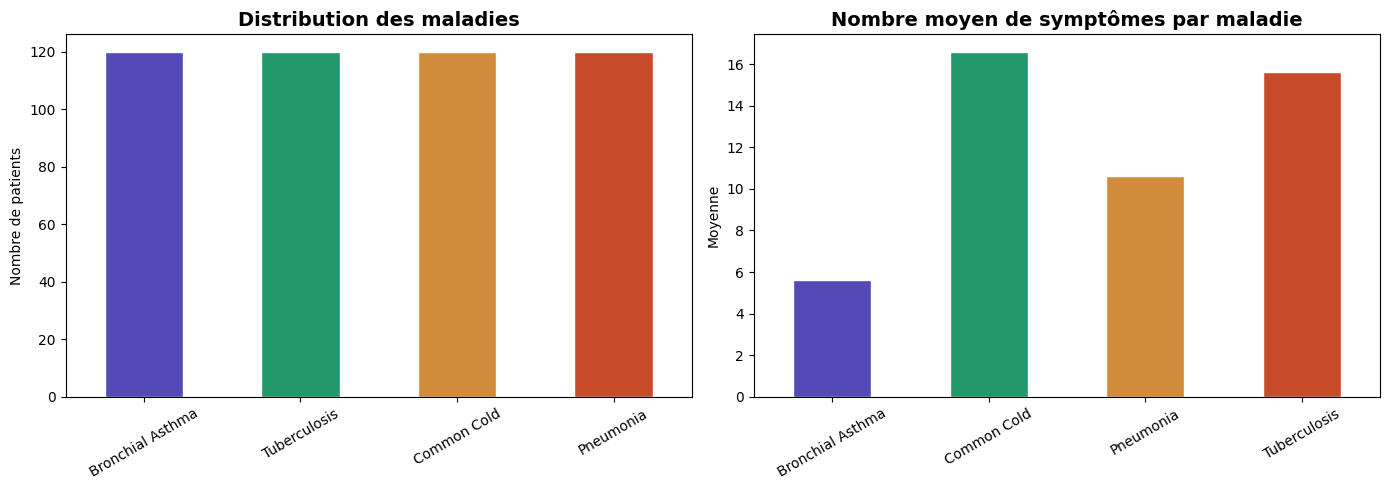

Graphique sauvegardé


In [12]:
# ============================================================
# VISUALISATION — Distribution des maladies
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution des maladies
df_resp['Disease'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#534AB7', '#22976A', '#D08C3B', '#C74B2A'],
    edgecolor='white'
)
axes[0].set_title('Distribution des maladies', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nombre de patients')
axes[0].tick_params(axis='x', rotation=30)

# Graphique 2 : Nombre de symptômes par patient
symptom_cols = [c for c in df_resp.columns if c.startswith('Symptom_')]
df_resp['nb_symptomes'] = df_resp[symptom_cols].notna().sum(axis=1)

df_resp.groupby('Disease')['nb_symptomes'].mean().plot(
    kind='bar',
    ax=axes[1],
    color=['#534AB7', '#22976A', '#D08C3B', '#C74B2A'],
    edgecolor='white'
)
axes[1].set_title('Nombre moyen de symptômes par maladie', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Moyenne')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('results/figures/distribution_maladies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

## 2. Construction du Contexte Formel (ACF)
Transformation du dataset en matrice binaire patients × symptômes.

In [13]:
# ============================================================
# CONSTRUCTION DU CONTEXTE FORMEL
# ============================================================

fc = FormalContext(df_resp)
binary_matrix = fc.build_context()

print(f"\nAperçu de la matrice binaire :")
print(binary_matrix.iloc[:5, :8])

Construction du contexte formel...
Contexte formel construit :
   480 patients
   29 symptômes uniques
   4 maladies

Aperçu de la matrice binaire :
   blood_in_sputum  breathlessness  chest_pain  chills  congestion  \
0                0               1           0       0           0   
1                0               1           0       0           0   
2                0               1           0       0           0   
3                0               1           0       0           0   
4                0               0           0       0           0   

   continuous_sneezing  cough  family_history  
0                    0      1               1  
1                    0      1               1  
2                    0      0               1  
3                    0      1               1  
4                    0      1               1  


## 3. Calcul des DAS (Ensembles Décisifs d'Attributs)
Application de l'algorithme ACF pour extraire les attributs minimaux
qui caractérisent chaque maladie.

In [14]:
# ============================================================
# CALCUL DES DAS POUR CHAQUE MALADIE
# ============================================================

das_dict = {}
for disease in maladies:
    das_dict[disease] = fc.compute_das(disease)

# Résumé
print("\n📊 Résumé des DAS trouvés :")
for disease, das_list in das_dict.items():
    print(f"  {disease} : {len(das_list)} DAS")


Calcul des DAS pour : Bronchial Asthma
6 DAS trouvés pour Bronchial Asthma

Calcul des DAS pour : Tuberculosis
16 DAS trouvés pour Tuberculosis

Calcul des DAS pour : Pneumonia
11 DAS trouvés pour Pneumonia

Calcul des DAS pour : Common Cold
17 DAS trouvés pour Common Cold

📊 Résumé des DAS trouvés :
  Bronchial Asthma : 6 DAS
  Tuberculosis : 16 DAS
  Pneumonia : 11 DAS
  Common Cold : 17 DAS


## 4. Génération des Règles Anchor
Transformation des DAS en règles interprétables avec calcul de couverture.
Format : IF symptôme(s) THEN maladie — Couverture = probabilité de prédiction correcte.

In [17]:
# ============================================================
# GÉNÉRATION DES RÈGLES ANCHOR
# ============================================================

df_rules = generate_rules(das_dict, binary_matrix)
save_rules(df_rules, 'results/rules/anchor_rules.csv')

print("\n📋 Top règles par maladie (couverture = 1.0) :")
top_rules = df_rules[df_rules['Couverture'] == 1.0][['Maladie', 'Règle', 'Couverture']]
print(top_rules.to_string(index=False))

Génération des règles Anchor...

--- Bronchial Asthma ---
  R1: IF breathlessness THEN Bronchial Asthma
       Couverture = 0.95
  R2: IF cough THEN Bronchial Asthma
       Couverture = 0.9
  R3: IF family_history THEN Bronchial Asthma
       Couverture = 0.95
  R4: IF fatigue THEN Bronchial Asthma
       Couverture = 0.9
  R5: IF high_fever THEN Bronchial Asthma
       Couverture = 0.95
  R6: IF mucoid_sputum THEN Bronchial Asthma
       Couverture = 0.95
--- Tuberculosis ---
  R1: IF blood_in_sputum THEN Tuberculosis
       Couverture = 1.0
  R2: IF breathlessness THEN Tuberculosis
       Couverture = 0.95
  R3: IF chest_pain THEN Tuberculosis
       Couverture = 1.0
  R4: IF chills THEN Tuberculosis
       Couverture = 0.95
  R5: IF cough THEN Tuberculosis
       Couverture = 0.95
  R6: IF fatigue THEN Tuberculosis
       Couverture = 0.95
  R7: IF high_fever THEN Tuberculosis
       Couverture = 0.95
  R8: IF loss_of_appetite THEN Tuberculosis
       Couverture = 1.0
  R9: IF malai

## 5. Visualisation des règles Anchor
Graphique de couverture par maladie.

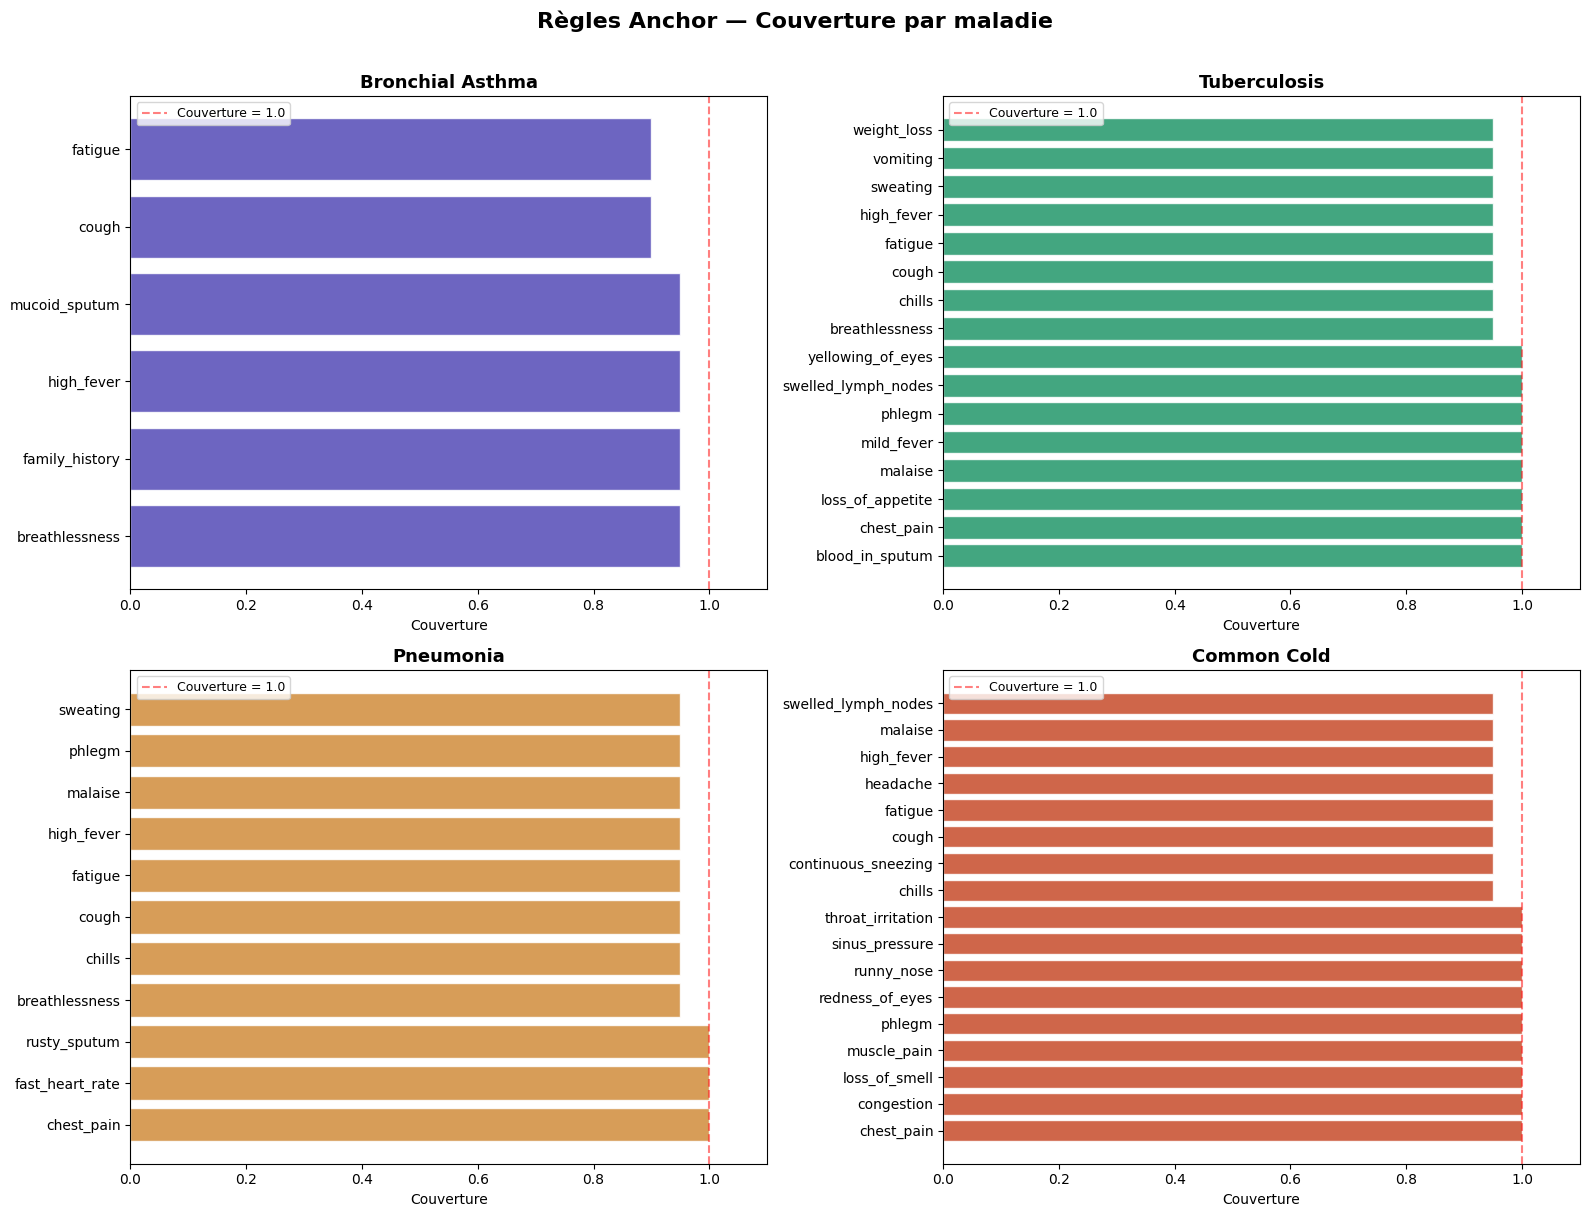

Graphique sauvegardé


In [20]:
# ============================================================
# VISUALISATION DES RÈGLES ANCHOR
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = {
    'Bronchial Asthma': '#534AB7',
    'Tuberculosis': '#22976A',
    'Pneumonia': '#D08C3B',
    'Common Cold': '#C74B2A'
}

for i, disease in enumerate(maladies):
    subset = df_rules[df_rules['Maladie'] == disease].copy()
    symptomes = subset['Règle'].str.replace(f' THEN {disease}', '').str.replace('IF ', '')
    
    axes[i].barh(
        symptomes,
        subset['Couverture'],
        color=colors[disease],
        edgecolor='white',
        alpha=0.85
    )
    axes[i].set_title(f'{disease}', fontsize=13, fontweight='bold')
    axes[i].set_xlim(0, 1.1)
    axes[i].set_xlabel('Couverture')
    axes[i].axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Couverture = 1.0')
    axes[i].legend(fontsize=9)

plt.suptitle('Règles Anchor — Couverture par maladie', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/anchor_rules_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

## 6. Classifieur XGBoost + Explicabilité SHAP
Comparaison avec une approche standard de ML interprétable.

In [21]:
# ============================================================
# PRÉPARATION DES DONNÉES POUR XGBOOST
# ============================================================
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb
import shap

# Utiliser la matrice binaire déjà construite
X = binary_matrix.drop(columns=['Disease'])
y = binary_matrix['Disease']

# Encoder les labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train : {X_train.shape[0]} patients")
print(f"Test  : {X_test.shape[0]} patients")
print(f"Classes : {le.classes_}")

Train : 384 patients
Test  : 96 patients
Classes : ['Bronchial Asthma' 'Common Cold' 'Pneumonia' 'Tuberculosis']


In [23]:
# ============================================================
# ENTRAÎNEMENT XGBOOST
# ============================================================

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print("Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Rapport de classification :

                  precision    recall  f1-score   support

Bronchial Asthma       1.00      1.00      1.00        24
     Common Cold       1.00      1.00      1.00        24
       Pneumonia       1.00      1.00      1.00        24
    Tuberculosis       1.00      1.00      1.00        24

        accuracy                           1.00        96
       macro avg       1.00      1.00      1.00        96
    weighted avg       1.00      1.00      1.00        96



<Figure size 1000x800 with 0 Axes>

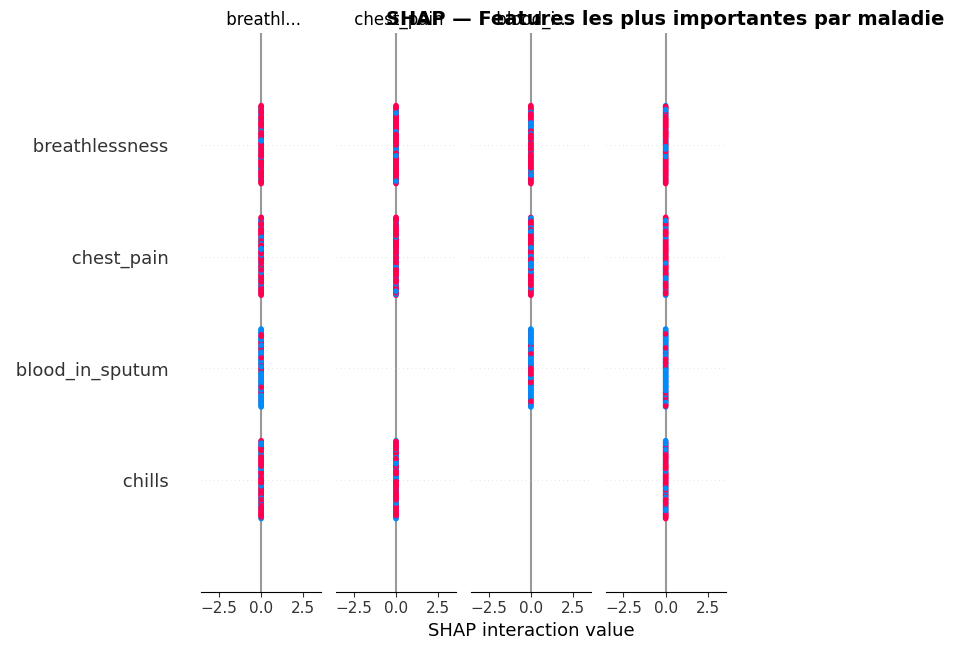

In [26]:
# ============================================================
# EXPLICABILITÉ SHAP
# ============================================================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualisation 1 : Summary plot — features les plus importantes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    class_names=le.classes_,
    show=False
)
plt.title('SHAP — Features les plus importantes par maladie', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/shap_summary.png', dpi=150, bbox_inches='tight')


## 7. Comparaison ACF+Anchor vs SHAP
Confrontation des deux approches d'explicabilité :
- **ACF+Anchor** : règles logiques extraites par analyse de concepts formels
- **SHAP** : importance des features par contribution marginale

In [28]:
# ============================================================
# COMPARAISON ACF+ANCHOR vs SHAP
# ============================================================

print("=" * 60)
print("COMPARAISON ACF+Anchor vs SHAP par maladie")
print("=" * 60)

for i, disease in enumerate(le.classes_):
    print(f"\n--- {disease} ---")
    
    # Top 5 features SHAP
    shap_imp = pd.Series(
        np.abs(shap_values[:, :, i]).mean(axis=0),
        index=X_test.columns
    ).sort_values(ascending=False).head(5)
    
    print("  SHAP top 5 features :")
    for feat, val in shap_imp.items():
        print(f"    {feat.strip()} : {val:.3f}")
    
    # DAS ACF correspondants
    disease_key = [k for k in das_dict.keys() if k == disease]
    if disease_key:
        das_symptoms = [d[0].strip() for d in das_dict[disease_key[0]]]
        print(f"  ACF DAS ({len(das_symptoms)}) :")
        for s in das_symptoms[:5]:
            print(f"    {s}")

print("\n Comparaison terminée")

COMPARAISON ACF+Anchor vs SHAP par maladie

--- Bronchial Asthma ---
  SHAP top 5 features :
    chest_pain : 3.002
    blood_in_sputum : 0.000
    breathlessness : 0.000
    chills : 0.000
    congestion : 0.000
  ACF DAS (6) :
    breathlessness
    cough
    family_history
    fatigue
    high_fever

--- Common Cold ---
  SHAP top 5 features :
    congestion : 3.002
    blood_in_sputum : 0.000
    breathlessness : 0.000
    chest_pain : 0.000
    chills : 0.000
  ACF DAS (17) :
    chest_pain
    chills
    congestion
    continuous_sneezing
    cough

--- Pneumonia ---
  SHAP top 5 features :
    fast_heart_rate : 3.002
    breathlessness : 0.000
    chest_pain : 0.000
    chills : 0.000
    blood_in_sputum : 0.000
  ACF DAS (11) :
    breathlessness
    chest_pain
    chills
    cough
    fast_heart_rate

--- Tuberculosis ---
  SHAP top 5 features :
    blood_in_sputum : 3.002
    breathlessness : 0.000
    chest_pain : 0.000
    chills : 0.000
    congestion : 0.000
  ACF DAS (16

## 8. Conclusion

Ce notebook présente une approche d'explicabilité basée sur l'Analyse de Concepts Formels (ACF) appliquée à la classification de maladies respiratoires.

**Ce qu'on a fait :**
- Construit un contexte formel à partir de 480 patients et 29 symptômes
- Extrait les attributs décisifs (DAS) pour 4 maladies respiratoires
- Généré 50 règles Anchor interprétables avec leur couverture
- Comparé avec l'approche SHAP standard

**Résultat clé :** Les deux méthodes identifient des features importantes différentes,
ce qui montre l'intérêt d'une approche complémentaire comme ACF+Anchor.

